In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.resnet50 import preprocess_input

2026-04-13 18:00:33.088801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776103233.485904      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776103233.591519      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776103234.580287      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776103234.580331      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776103234.580334      55 computation_placer.cc:177] computation placer alr

In [2]:
dataset, info = tfds.load(
    "plant_village",
    split="train",
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.KQ5JMA_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


I0000 00:00:1776103424.290707      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776103424.296717      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
IMG_SIZE = 96
BATCH_SIZE = 16   # Kaggle GPU can handle more

In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label


In [5]:
dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.cache()
dataset = dataset.shuffle(10000)

In [6]:
N = 54303
train_size = int(0.8 * N)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
train_labels = []
for _, y in train_ds.unbatch():
    train_labels.append(y.numpy())

train_labels = np.array(train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(info.features["label"].num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/8


I0000 00:00:1776103467.873473     358 service.cc:152] XLA service 0x7bc470050600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776103467.873521     358 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776103467.873527     358 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776103469.786794     358 cuda_dnn.cc:529] Loaded cuDNN version 91002


   8/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.0313 - loss: 5.6289      

I0000 00:00:1776103474.173392     358 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 98s 30ms/step - accuracy: 0.5687 - loss: 1.6759 - val_accuracy: 0.8882 - val_loss: 0.3582
Epoch 2/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.7931 - loss: 0.6715 - val_accuracy: 0.9067 - val_loss: 0.2803
Epoch 3/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8206 - loss: 0.5576 - val_accuracy: 0.8997 - val_loss: 0.3046
Epoch 4/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8411 - loss: 0.4968 - val_accuracy: 0.9244 - val_loss: 0.2391
Epoch 5/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8545 - loss: 0.4422 - val_accuracy: 0.9285 - val_loss: 0.2152
Epoch 6/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8685 - loss: 0.4074 - val_accuracy: 0.9402 - val_loss: 0.1825
Epoch 7/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8743 - loss: 0.3863 - val_accuracy: 0.9317 - val_loss: 0.2153
Epoch 8/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8701 - loss: 0.4042 - va

In [10]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuned_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 101s 31ms/step - accuracy: 0.7048 - loss: 1.2785 - val_accuracy: 0.9352 - val_loss: 0.2034
Epoch 2/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 71s 26ms/step - accuracy: 0.8580 - loss: 0.4158 - val_accuracy: 0.9564 - val_loss: 0.1425
Epoch 3/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 71s 26ms/step - accuracy: 0.8957 - loss: 0.2878 - val_accuracy: 0.9733 - val_loss: 0.0948
Epoch 4/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - accuracy: 0.9201 - loss: 0.2186 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 5/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - accuracy: 0.9336 - loss: 0.1771 - val_accuracy: 0.9820 - val_loss: 0.0619
Epoch 6/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - accuracy: 0.9454 - loss: 0.1479 - val_accuracy: 0.9853 - val_loss: 0.0475
Epoch 7/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - accuracy: 0.9558 - loss: 0.1210 - val_accuracy: 0.9849 - val_loss: 0.0494
Epoch 8/8
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 70s 26ms/step - accuracy: 0.9606 - loss: 

In [11]:
y_true, y_pred = [], []

for x, y in val_ds:
    p = resnet_model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(p, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━

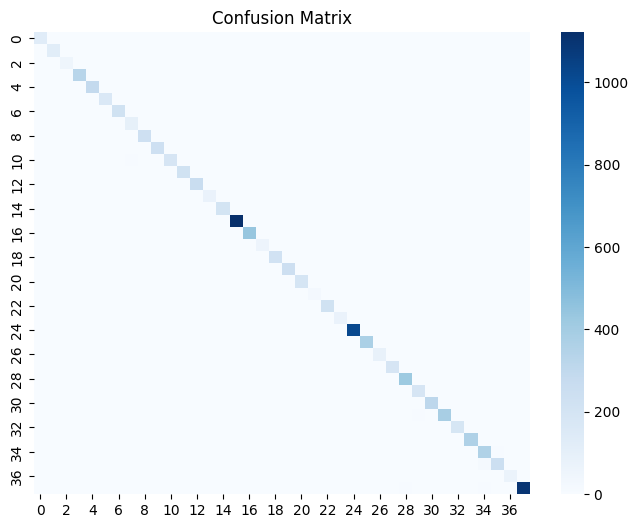

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

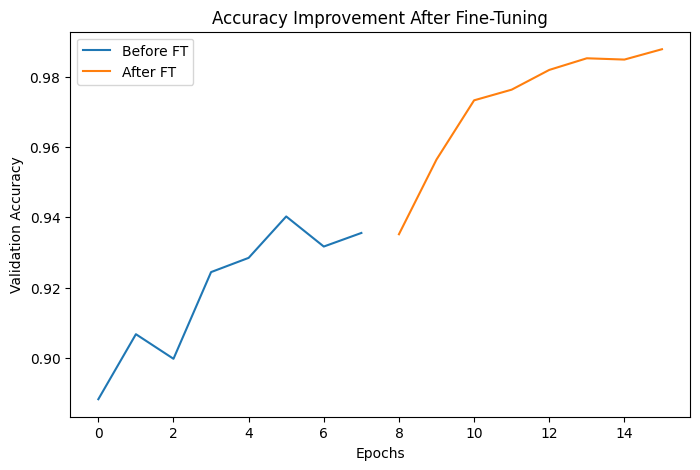

In [13]:
plt.figure(figsize=(8,5))

# Before fine-tuning
plt.plot(range(len(resnet_history.history['val_accuracy'])),
         resnet_history.history['val_accuracy'],
         label='Before FT')

# After fine-tuning (continue x-axis)
plt.plot(range(len(resnet_history.history['val_accuracy']),
               len(resnet_history.history['val_accuracy']) + len(fine_tuned_history.history['val_accuracy'])),
         fine_tuned_history.history['val_accuracy'],
         label='After FT')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy Improvement After Fine-Tuning")
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(info.features["label"].num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
small_train = train_ds.unbatch().take(2000).batch(BATCH_SIZE)
small_val = val_ds.unbatch().take(500).batch(BATCH_SIZE)

cnn_history = cnn_model.fit(
    small_train,
    validation_data=small_val,
    epochs=8
)

Epoch 1/8
    125/Unknown 4s 6ms/step - accuracy: 0.1133 - loss: 27.2016

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1137 - loss: 27.0611 - val_accuracy: 0.2820 - val_loss: 2.8993
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3258 - loss: 2.7288 - val_accuracy: 0.3840 - val_loss: 2.4129
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4540 - loss: 2.1340 - val_accuracy: 0.4580 - val_loss: 2.1652
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4999 - loss: 1.9593 - val_accuracy: 0.4240 - val_loss: 2.2037
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5409 - loss: 1.7545 - val_accuracy: 0.4380 - val_loss: 2.2422
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5683 - loss: 1.5591 - val_accuracy: 0.5160 - val_loss: 1.7705
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6299 - loss: 1.4185 - val_accuracy: 0.5260 - val_loss: 1.9961
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6364 - loss: 1.2989 - val_accuracy: 0.4980 - val_loss:

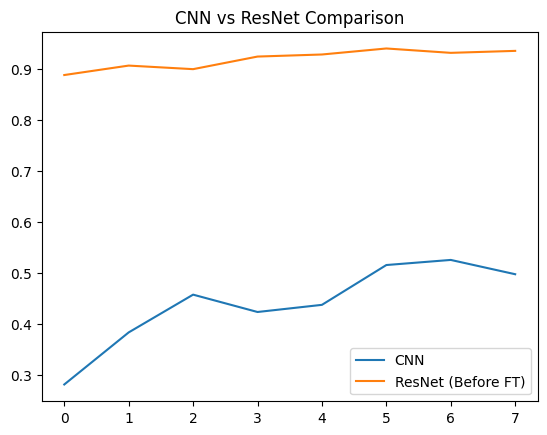

In [16]:
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet (Before FT)')

plt.legend()
plt.title("CNN vs ResNet Comparison")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


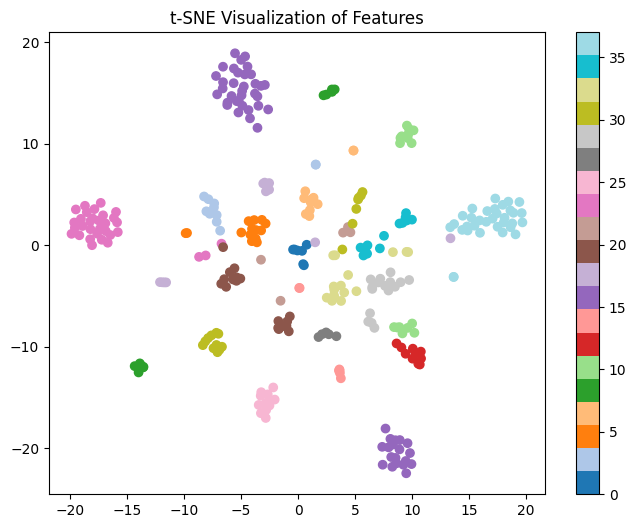

In [17]:
from sklearn.manifold import TSNE

# Extract features using ResNet (without classifier)
feature_model = Model(inputs=resnet_model.input, outputs=resnet_model.layers[-3].output)

features = []
labels_list = []

for images, labels in val_ds.take(20):   # small subset for speed
    f = feature_model.predict(images)
    features.append(f)
    labels_list.append(labels.numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=labels_list, cmap='tab20')
plt.title("t-SNE Visualization of Features")
plt.colorbar()
plt.show()

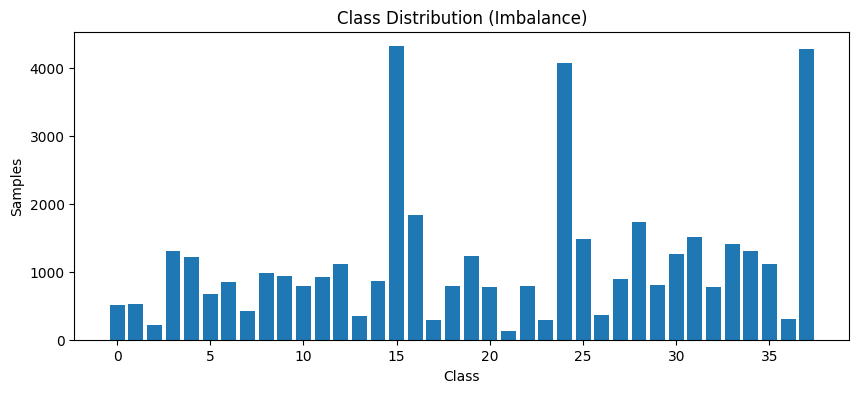

In [18]:
import collections

counter = collections.Counter(train_labels)

plt.figure(figsize=(10,4))
plt.bar(counter.keys(), counter.values())
plt.title("Class Distribution (Imbalance)")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.show()

In [19]:
top_k = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)

y_scores = resnet_model.predict(val_ds)
top_k.update_state(y_true, y_scores)

print("Top-3 Accuracy:", top_k.result().numpy())

679/679 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step
Top-3 Accuracy: 0.111223646


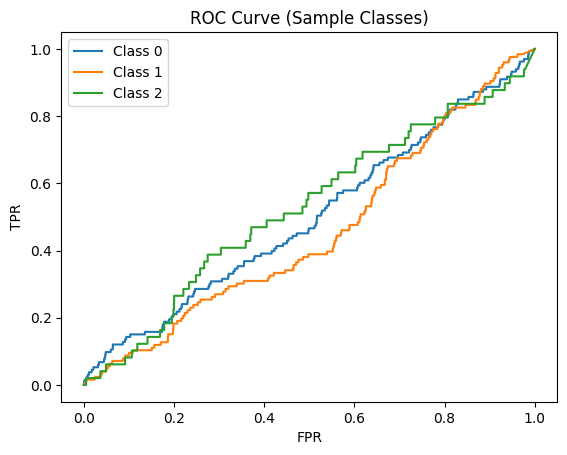

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

y_true_bin = label_binarize(y_true, classes=range(info.features["label"].num_classes))

plt.figure()

for i in range(3):   # only first 3 classes for speed
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.legend()
plt.title("ROC Curve (Sample Classes)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 96, 96, 3))']
  warnings.warn(msg)


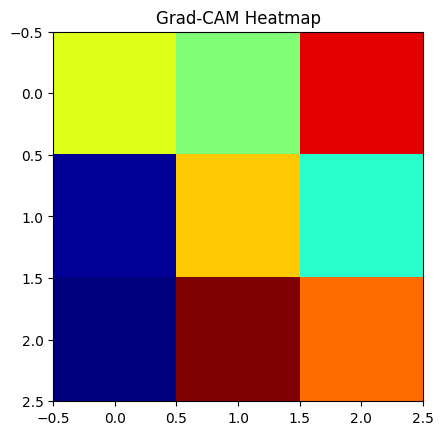

In [21]:
last_conv_layer = resnet_model.get_layer("conv5_block3_out")

grad_model = tf.keras.models.Model(
    [resnet_model.inputs],
    [last_conv_layer.output, resnet_model.output]
)

def gradcam(image):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(tf.expand_dims(image, axis=0))
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Test Grad-CAM
sample_img = next(iter(val_ds))[0][0]
heatmap = gradcam(sample_img)

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.show()

In [27]:
resnet_model.save("plant_disease_model.h5")

In [23]:
!pip install gradio

In [24]:
from tensorflow.keras.models import load_model

model = load_model("plant_disease_model.h5")

class_names = info.features["label"].names
IMG_SIZE = 96

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict(image):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    image = np.expand_dims(image, axis=0)

    preds = model.predict(image)[0]
    idx = np.argmax(preds)

    return f"{class_names[idx]} ({preds[idx]*100:.2f}%)"

In [26]:
import gradio as gr
gr.close_all()
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="🌿 Plant Disease Detection",
    description="Upload a leaf image to detect plant disease"
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c6a6204e34167cc437.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
